Based on routes in processed data, resample images and poses from raw data.

In [26]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("/home/zhaohaoa/cadc/cadc_devkit")
sys.path.append("/home/zhaohaoa/cadc/utils")

import pickle
import numpy as np
import matplotlib.pyplot as plt
import cv2
import yaml
import load_novatel_data, convert_novatel_to_pose
from pathlib import Path

from processing_utils import load_data, load_timestamps, convert_to_2d, infer_direction_2d, plot_poses_2d

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
LABELLED_DATA_DIR = r"/home/zhaohaoa/cadc/cadcd"
RAW_DATA_DIR = r"/home/zhaohaoa/cadc/cadcd_raw"
CUT_INDICES_PATH = r"/home/zhaohaoa/cadc/cut_indices.pkl" # Dict of cut indices for each trajectory (optional)

CADC_TO_NAVSIM_CAMERA_MAPPING = {
    "00": "cam_f0",
    "01": "cam_r0",
    "02": "cam_r1",
    "03": "cam_r2",
    "04": "cam_b0",
    "05": "cam_l2",
    "06": "cam_l1",
    "07": "cam_l0"
}


In [28]:
def find_closest_timestamp_inds(target_times, timestamps):
    '''
    Find indices of the closest timestamps in 'timestamps' for each time in 'target_times'.
    Args:
        target_times (np.ndarray): Array of target timestamps to find closest matches for.
        timestamps (np.ndarray): Array of timestamps to search within.
    Returns:
        np.ndarray: Array of indices of the closest timestamps in 'timestamps' for each target time.
    '''
    idx = np.searchsorted(timestamps, target_times)
    idx = np.clip(idx, 1, len(timestamps)-1)
    left = idx - 1
    right = idx
    choose_right = (timestamps[right] - target_times) < (target_times - timestamps[left])
    return np.where(choose_right, right, left)

def extract_pos_vel_acc(raw_path):
    '''
    Extract 2D poses, velocities in vehicle frame, and IMU accelerations from Novatel data. Output data in 2Hz.
    Args:
        raw_path (Path): Path to the raw data directory.
    Returns:
        dict: A dictionary containing:
            poses (np.ndarray): Nx4 array of 2D poses (x, y, yaw).
            vel (np.ndarray): Nx2 array of velocities in vehicle frame (v_x, v_y). 
            acc (np.ndarray): Nx2 array of accelerations in vehicle frame (a_x, a_y).
            times (np.ndarray): N array of timestamps for poses and velocities.
            imu_times (np.ndarray): N array of timestamps for IMU data. 
            start_time_pose (float): Start time for pose data.
    '''

    novatel_data_path = raw_path / "raw" / "novatel" / "data"
    novatel_ts_path = raw_path / "raw" / "novatel" / "timestamps.txt"
    novatel_imu_data_path = raw_path / "raw" / "novatel_imu" / "data"
    novatel_imu_ts_path = raw_path / "raw" / "novatel_imu" / "timestamps.txt"

    # Data format:
    # latitude (degrees)
    # longitude (degrees)
    # altitude (m)
    # undulation (m)
    # latitude_std (m)
    # longitude_std (m)
    # altitude_std (m)
    # roll (degrees)
    # pitch (degrees)
    # azimuth (degrees)
    # roll_std (degrees)
    # pitch_std (degrees)
    # azimuth_std (degrees)
    # ins_status
    # position_type
    # extended_status
    # seconds_since_update (seconds)
    # north_velocity (m/s)
    # east_velocity (m/s)
    # up_velocity (m/s)
    # north_velocity_std (m/s)
    # east_velocity_std (m/s)
    # up_velocity_std (m/s)
    novatel_data = load_data(novatel_data_path)
    poses = convert_novatel_to_pose.convert_novatel_to_pose(novatel_data)
    times, start_time = load_timestamps(novatel_ts_path) 
    # This is at 20 Hz. Downsample to 2 Hz by taking every 10th frame
    poses_downsampled = poses[::10]
    times_downsampled = times[::10]
    poses_2d = convert_to_2d(poses_downsampled) # Convert to 2D
    yaw = np.deg2rad(90 - novatel_data[::10, 9]) # Azimuth in radians

    # Convert world -> vehicle (x forward, y left): rotate by -yaw
    v_n = novatel_data[::10, 17]                    # North
    v_e = novatel_data[::10, 18]                    # East
    v_x =  v_e * np.cos(yaw) + v_n * np.sin(yaw)
    v_y = -v_e * np.sin(yaw) + v_n * np.cos(yaw)
    velocities_vehicle_frame = np.stack([v_x, v_y], axis=1)

    # Novatel IMU data
    # Format:
    # pitch_rate (rad/sample)
    # roll_rate (rad/sample)
    # yaw_rate (rad/sample)
    # x_accel (m/s/sample)
    # y_accel (m/s/sample)
    # z_accel (m/s/sample)
    novatel_imu_data = load_data(novatel_imu_data_path)
    novatel_imu_times, novatel_imu_start_time = load_timestamps(novatel_imu_ts_path)
    novatel_imu_times_aligned = novatel_imu_times + (np.timedelta64(novatel_imu_start_time - start_time) / np.timedelta64(1, 's')) # align start times
    # Find corresponding indices in novatel_imu_times for times_downsampled
    novatel_imu_indices = find_closest_timestamp_inds(times_downsampled, novatel_imu_times_aligned)

    acc_downsampled = novatel_imu_data[novatel_imu_indices, 3:5] * 100  # Convert from per sample to per second (100 Hz)
    acc_times_downsampled = novatel_imu_times_aligned[novatel_imu_indices]

    # Convert to vehicle frame
    acc_lat = acc_downsampled[:, 0] # right
    acc_lon = acc_downsampled[:, 1] # forward

    acc_x = acc_lon
    acc_y = -acc_lat

    # Return dictionary
    return {
        "poses": poses_2d,
        "velocities": velocities_vehicle_frame,
        "accelerations": np.stack([acc_x, acc_y], axis=1),
        "pose_times": times_downsampled,
        "imu_times": acc_times_downsampled,
        "start_time_pose": start_time,
    }

In [29]:
def undistort_image(image, K, dist_coeffs):
    h, w = image.shape[:2]
    # new_K, _ = cv2.getOptimalNewCameraMatrix(K, dist_coeffs, (w, h), 1, (w, h))
    undistorted_image = cv2.undistort(image, K, dist_coeffs, None, K)
    return undistorted_image


def load_images_and_calibrations(camera, pose_times, pose_start_time, run_path, raw_path):
    '''
    Load images and camera calibration for a given camera.
    Args:
        camera (str): Camera identifier (e.g., "00", "01", ..., "07").
        pose_times (np.ndarray): Array of pose timestamps to align images with.
        pose_start_time (float): Start time for pose data to align timestamps.
        run_path (Path): Path to the labeled data directory.
        raw_path (Path): Path to the raw data directory.
    Returns:
        dict: A dictionary containing:
            camera_intrinsic (np.ndarray): 3x3 camera intrinsic matrix.
            distortion (np.ndarray): Distortion coefficients.
            camera_to_lidar (np.ndarray): 4x4 transformation matrix from camera to LiDAR.
            images_sampled (list of Path): List of image file paths sampled at pose timestamps.
            image_sampled_times (np.ndarray): Array of timestamps for the sampled images.
    '''

    camera_intrinsics_yaml_path = run_path.parent / "calib" / f"{camera}.yaml"
    camera_extrinsics_yaml_path = run_path.parent / "calib" / f"extrinsics.yaml"

    with open(camera_intrinsics_yaml_path, 'r') as f:
        camera_intrinsics = yaml.safe_load(f)
    with open(camera_extrinsics_yaml_path, 'r') as f:
        camera_extrinsics = yaml.safe_load(f)

    K = np.array(camera_intrinsics['camera_matrix']['data']).reshape(3,3)
    dist = np.array(camera_intrinsics['distortion_coefficients']['data'], dtype=np.float32)
    T_camera2lidar = np.array(camera_extrinsics[f'T_LIDAR_CAM{camera}']).reshape(4,4)

    # Find images closest to the pose timestamps
    image_dir = raw_path / "raw" / f"image_{camera}" / "data"
    image_ts_path = raw_path / "raw" / f"image_{camera}" / "timestamps.txt"
    image_times, image_start_time = load_timestamps(image_ts_path)

    # align start times
    image_times_aligned = image_times + (np.timedelta64(image_start_time - pose_start_time) / np.timedelta64(1, 's'))

    # Find corresponding indices in image_times for pose times
    image_indices = find_closest_timestamp_inds(pose_times, image_times_aligned)

    images_sampled = sorted(image_dir.glob("*.png"))
    images_sampled = [images_sampled[i] for i in image_indices]
    image_sampled_times = image_times_aligned[image_indices]

    assert len(images_sampled) == len(pose_times), "Number of sampled images does not match number of pose timestamps."

    return {
        "camera_intrinsic": K,
        "distortion": dist,
        "camera_to_lidar": T_camera2lidar,
        "images_sampled": images_sampled,
        "image_sampled_times": image_sampled_times,
    }

In [30]:
save_path = Path(r"/home/zhaohaoa/navsim/dataset/navsim_logs/cadc")
data_base_path = Path(r"/home/zhaohaoa/cadc/cadcd")

run_paths = sorted(data_base_path.glob("*/*"))
# Load cut indices if exists
if Path(CUT_INDICES_PATH).exists():
    with open(CUT_INDICES_PATH, 'rb') as f:
        cut_indices_dict = pickle.load(f)  
else:
    cut_indices_dict = {}

# run_path = Path(r"/home/zhaohaoa/cadc/cadcd/2018_03_06/0001")
# raw_path = Path(r"/home/zhaohaoa/cadc/cadcd_raw/2018_03_06/0001")

for run_path in run_paths:
    if run_path.name == "calib": continue

    raw_path = data_base_path.parent / "cadcd_raw" / run_path.relative_to(data_base_path)

    pose_dict = extract_pos_vel_acc(raw_path)
    poses = pose_dict["poses"]
    vels = pose_dict["velocities"]
    accs = pose_dict["accelerations"]
    times = pose_dict["pose_times"]
    start_time_pose = pose_dict["start_time_pose"]
    assert len(poses) == len(vels) == len(accs) == len(times)

    direction = infer_direction_2d(poses, yaw_deg=20)

    cameras = ["0" + str(i) for i in range(8)]  # Assuming 8 cameras: 0-7
    camera_data = {}
    for cam in cameras:
        cam_data = load_images_and_calibrations(cam, times, start_time_pose, run_path, raw_path)
        camera_data[cam] = cam_data

    # Crop indices
    if str(run_path.relative_to(data_base_path)) in cut_indices_dict:
        # print("Using cut indices:", cut_indices_dict[str(run_path.relative_to(data_base_path))])
        start, end = cut_indices_dict[str(run_path.relative_to(data_base_path))]
        start = start % len(poses)
        end = end % len(poses) 
        cut_indices = (start, end) 
        
    else:
        cut_indices = (0, len(poses))

    # List of frames at each time step
    data = [{
        "pose": poses[i],
        "velocity": vels[i],
        "acceleration": accs[i],
        "time": times[i],
        "direction": direction,
        "camera_images": {CADC_TO_NAVSIM_CAMERA_MAPPING[cam]: camera_data[cam]["images_sampled"][i] for cam in cameras},
        "camera_intrinsics": {CADC_TO_NAVSIM_CAMERA_MAPPING[cam]: camera_data[cam]["camera_intrinsic"] for cam in cameras},
        "camera_distortions": {CADC_TO_NAVSIM_CAMERA_MAPPING[cam]: camera_data[cam]["distortion"] for cam in cameras},
        "camera_to_lidar": {CADC_TO_NAVSIM_CAMERA_MAPPING[cam]: camera_data[cam]["camera_to_lidar"] for cam in cameras},
        "token": f"{run_path.parent.name}_{run_path.name}_{i}",
        "log_name": run_path.relative_to(data_base_path).as_posix(),
    } for i in range(cut_indices[0], cut_indices[1])]


    # Save the entire run as a pickle file
    save_file_path = save_path / run_path.parent.name / f"{run_path.name}.pkl"
    save_file_path.parent.mkdir(parents=True, exist_ok=True)
    with open(save_file_path, 'wb') as f:
        pickle.dump(data, f)



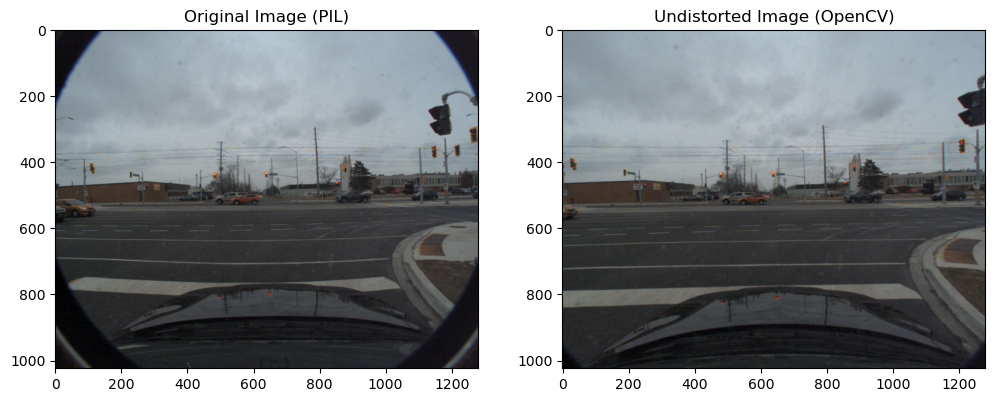

In [14]:
test_data = data[0]

import cv2
from PIL import Image


img_path = test_data["camera_images"]["cam_f0"]

img = cv2.imread(img_path)


K = test_data["camera_intrinsics"]["cam_f0"]
dist = test_data["camera_distortions"]["cam_f0"]

# h, w = img.shape[:2]
# newK, roi = cv2.getOptimalNewCameraMatrix(K, dist, (w, h), alpha=0)
undistorted = cv2.undistort(img, K, dist, None, K)

# open with PIL to check if it works
img_pil = np.array(Image.open(img_path))

# Plot
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
# ax1.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
# ax1.set_title("Original Image")
# ax2.imshow(cv2.cvtColor(undistorted, cv2.COLOR_BGR2RGB))
# ax2.set_title("Undistorted Image")
# plt.show()

# Plot undistorted image with pil image
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.imshow(img_pil)
ax1.set_title("Original Image (PIL)")
ax2.imshow(cv2.cvtColor(undistorted, cv2.COLOR_BGR2RGB))
ax2.set_title("Undistorted Image (OpenCV)")
plt.show()

In [6]:
def integrate_pos_from_acc_with_yaw(
    times,
    acc_body,
    yaw,
    p0=(0.0, 0.0),     # initial (E, N) in meters
    v0=(0.0, 0.0),     # initial (vE, vN) in m/s
    y_is_right=False,
    remove_bias=True,
    bias_seconds=1.0,  # estimate accel bias from first bias_seconds
):
    t = np.asarray(times, dtype=float)
    a = np.asarray(acc_body, dtype=float)
    yaw = np.asarray(yaw, dtype=float)

    if a.shape[1] != 2:
        raise ValueError("acc_body must be Nx2: [a_x, a_y]")

    if y_is_right:
        a[:, 1] *= -1.0  # convert to y-left

    # Optional: estimate and remove constant accel bias from early samples
    if remove_bias and len(t) >= 2:
        t0 = t[0]
        mask = t <= (t0 + bias_seconds)
        if np.any(mask):
            a = a - np.mean(a[mask], axis=0, keepdims=True)

    c = np.cos(yaw)
    s = np.sin(yaw)

    ax = a[:, 0]
    ay = a[:, 1]

    # body -> world(ENU): [aE, aN]^T = R(yaw) * [ax, ay]^T
    aE = c * ax - s * ay
    aN = s * ax + c * ay
    a_world = np.stack([aE, aN], axis=1)

    dt = np.diff(t)
    if np.any(dt <= 0):
        raise ValueError("times must be strictly increasing")

    # Integrate accel -> velocity (trapezoid)
    v = np.empty_like(a_world)
    v[0] = np.array(v0, dtype=float)
    v[1:] = v[0] + np.cumsum(0.5 * (a_world[:-1] + a_world[1:]) * dt[:, None], axis=0)

    # Integrate velocity -> position (trapezoid)
    p = np.empty_like(a_world)
    p[0] = np.array(p0, dtype=float)
    p[1:] = p[0] + np.cumsum(0.5 * (v[:-1] + v[1:]) * dt[:, None], axis=0)

    return p, v, a_world

# Derive positions from novatel velocities
# inputs: times (seconds), v_body (Nx2), azimuth_deg (N,)
# v_body[:,0]=v_x forward (m/s), v_body[:,1]=v_y left (m/s)
def integrate_positions_from_body_vel(times, v_body, azimuth_deg,
                                      E0=0.0, N0=0.0, y_is_right=False):
    t = np.asarray(times)
    vx = np.asarray(v_body)[:, 0]
    vy = np.asarray(v_body)[:, 1]

    if y_is_right:
        vy = -vy  # convert right-positive to left-positive

    # yaw CCW from East
    yaw = np.deg2rad(90.0 - np.asarray(azimuth_deg))

    c = np.cos(yaw)
    s = np.sin(yaw)

    # body -> ENU
    vE = c * vx - s * vy
    vN = s * vx + c * vy

    dt = np.diff(t)
    # trapezoidal integration
    E = np.empty_like(t, dtype=float)
    N = np.empty_like(t, dtype=float)
    E[0], N[0] = E0, N0
    E[1:] = E0 + np.cumsum(0.5 * (vE[:-1] + vE[1:]) * dt)
    N[1:] = N0 + np.cumsum(0.5 * (vN[:-1] + vN[1:]) * dt)

    return np.stack([E, N], axis=1), np.stack([vE, vN], axis=1)